# Automated Disease Detection from Chest X-Ray Images

### **Problem Statement**

Chest X-ray analysis is widely used to detect lung diseases, but manual review can be time-consuming in high-volume clinical settings.

This project builds a model to automatically classify X-ray images into disease categories.

---

### **Dataset**

Chest X-ray images organized into 3 classes:

- COVID
- NORMAL
- PNEUMONIA

---

### **Model**

CNN (inspired by VGG)

```
Input (224×224)
→ Conv → ReLU → Conv → ReLU → Pool
→ Conv → ReLU → Conv → ReLU → Pool
→ Conv → ReLU → Pool
→ Flatten → Dense → Output (3 classes)
```

---

### **Workflow**

Data → Preprocess → Train → Evaluate → Predict

---

### **Goal**

Train a model to classify unseen chest X-ray images.

### **Install Dependencies & Import Libraries**

We install and import the required libraries for building and training the model.

- **torch / torch.nn** → model building
- **DataLoader / Dataset** → handling image data
- **PIL / numpy** → image processing
- **sklearn** → splitting and evaluation
- **matplotlib / seabornn** → visualization

In [ ]:
!pip install torch torchvision scikit-learn matplotlib

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
# PIL stands for Python Imaging Library.
# It’s a library used to work with images in Python (like opening, editing, and saving images).

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## **Data Loading Setup**

- [Click Here](https://www.kaggle.com/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images/data) to download the dataset.
- It will be in a ZIP format.
- Extract the ZIP file into a folder.
- After extraction, you will see three folders: COVID, NORMAL, and PNEUMONIA.
- You can either:
  - Upload the ZIP file directly into Google Colab, or
  - Load the extracted folders in Jupyter Notebook or VS Code using their file paths.


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# **Load & Prepare Data**

### **Dataset Overview**

The dataset is organized into 3 folders:

- **COVID** — 1626 images
- **NORMAL** — 1802 images
- **PNEUMONIA** — 1800 images

All images are:

- Preprocessed and resized to **256×256**
- Stored in **PNG format**
- Grayscale chest X-ray scans

Each folder represents one class.

---

In [ ]:
print(os.listdir("dataset"))

['COVID', 'PNEUMONIA', 'NORMAL']


In [ ]:
print(os.listdir("dataset/COVID"))

['COVID_1071.png', 'COVID_1024.png', 'COVID_506.png', 'COVID_1148.png', 'COVID_472.png', 'COVID_1228.png', 'COVID_429.png', 'COVID_217.png', 'COVID_833.png', 'COVID_617.png', 'COVID_1119.png', 'COVID_1124.png', 'COVID_1083.png', 'COVID_343.png', 'COVID_974.png', 'COVID_1088.png', 'COVID_724.png', 'COVID_1287.png', 'COVID_609.png', 'COVID_491.png', 'COVID_398.png', 'COVID_1535.png', 'COVID_335.png', 'COVID_492.png', 'COVID_1548.png', 'COVID_1388.png', 'COVID_669.png', 'COVID_1157.png', 'COVID_961.png', 'COVID_224.png', 'COVID_1245.png', 'COVID_1416.png', 'COVID_1183.png', 'COVID_796.png', 'COVID_1176.png', 'COVID_27.png', 'COVID_1423.png', 'COVID_905.png', 'COVID_1503.png', 'COVID_578.png', 'COVID_481.png', 'COVID_798.png', 'COVID_66.png', 'COVID_640.png', 'COVID_1360.png', 'COVID_1021.png', 'COVID_1626.png', 'COVID_498.png', 'COVID_1103.png', 'COVID_239.png', 'COVID_1361.png', 'COVID_1254.png', 'COVID_544.png', 'COVID_182.png', 'COVID_1150.png', 'COVID_1422.png', 'COVID_243.png', 'COVI

In [ ]:
dataset_path = "dataset"

data = []

for label in os.listdir(dataset_path):   # COVID, NORMAL, PNEUMONIA
    class_path = os.path.join(dataset_path, label)

    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        data.append([img_path, label])



In [ ]:
df = pd.DataFrame(data, columns=["image_path", "label"])



In [ ]:
df.head()

,image_path,label
0,dataset/COVID/COVID_1071.png,COVID
1,dataset/COVID/COVID_1024.png,COVID
2,dataset/COVID/COVID_506.png,COVID
3,dataset/COVID/COVID_1148.png,COVID
4,dataset/COVID/COVID_472.png,COVID


## **Checking the data**

In [ ]:
print("Total images:", len(df))
print(df["label"].value_counts())

Total images: 5228
label
NORMAL       1802
PNEUMONIA    1800
COVID        1626
Name: count, dtype: int64


# **Visualise Sample Images**

Before training, we inspect a few images to confirm:

- Images are loaded correctly
- Labels match the class (COVID / NORMAL / PNEUMONIA)
- Preprocessing (resize, normalization) is working as expected

Each image is a chest X-ray with its corresponding class label shown above.

---

## **Balanced Sampling for Visualization**

We sample images from each class to ensure all categories are visible.

- Helps verify that all classes are loaded correctly
- Provides a balanced view of the dataset
- Avoids biased or misleading visualization

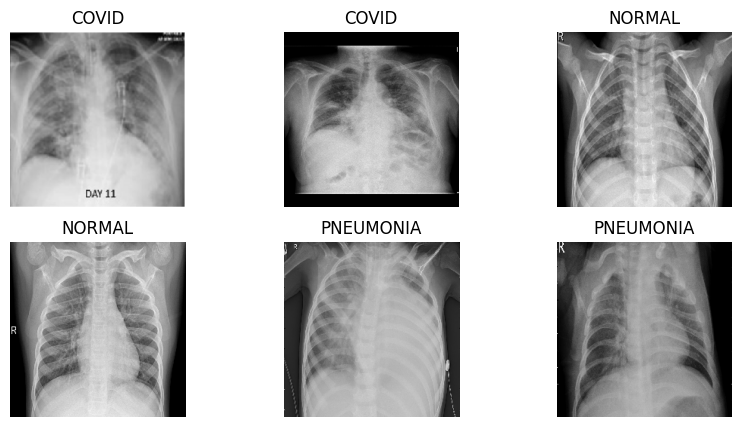

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
# PIL stands for Python Imaging Library.
# It’s a library used to work with images in Python (like opening, editing, and saving images).

plt.figure(figsize=(10,5))

classes = ["COVID", "NORMAL", "PNEUMONIA"]
i = 1

for cls in classes:
    sample_df = df[df["label"] == cls].sample(2)  # 2 images per class

    for _, row in sample_df.iterrows():
        img = Image.open(row["image_path"])

        plt.subplot(2,3,i)
        plt.imshow(img, cmap='gray')
        plt.title(row["label"])
        plt.axis('off')

        i += 1

plt.show()

### **Dataset Split**

We split the dataset into:

- **Training set (80%)** — used to train the model
- **Validation set (20%)** — used to evaluate during training

This helps measure how well the model performs on unseen data.

---

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],   # keeps class balance
    random_state=42
)

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 4182
Validation size: 1046


### **Checking the distribution**

In [ ]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

label
NORMAL       1441
PNEUMONIA    1440
COVID        1301
Name: count, dtype: int64
label
NORMAL       361
PNEUMONIA    360
COVID        325
Name: count, dtype: int64


“We split data so model doesn’t just memorize”

“Validation helps us check performance on unseen data”

# **Preprocessing**

Now we prepare images before feeding into model:

- **Resize (224×224)** — standard input size for the model
- **Grayscale** — ensures single-channel input
- **Normalize (0–1)** — scales pixel values for stable training

---



**Keep it clean:**

- Resize → same size for all images
- Grayscale → reduce complexity
- Normalize → helps model learn better

In [ ]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = Image.open(img_path).convert("L")   # grayscale
    img = img.resize((IMG_SIZE, IMG_SIZE))    # resize

    img = np.array(img) / 255.0               # normalize (0–1)

    return img

In [ ]:
sample_img = preprocess_image(train_df["image_path"].iloc[0])

In [ ]:
print(sample_img.shape)

(224, 224)


### **Visualize processed image**

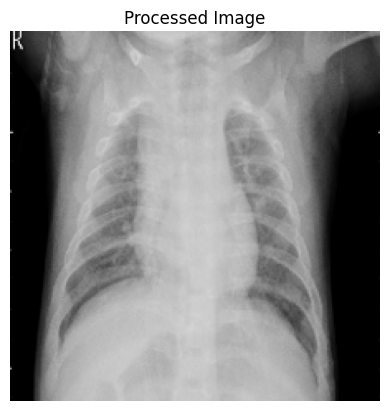

In [ ]:
plt.imshow(sample_img, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

# **Creating PyTorch Dataset**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

## Label Encoding (important)

Models don’t understand text → convert to numbers

In [ ]:
label_map = {
    "COVID": 0,
    "NORMAL": 1,
    "PNEUMONIA": 2
}

## **Create Custom Dataset**

We create a custom dataset class to load and preprocess images for the model.

### **What this does**

- Reads image paths and labels from the DataFrame
- Loads each image from disk
- Converts image to grayscale
- Resizes to **224×224** (model input size)
- Normalizes pixel values (0–255 → 0–1)
- Adds channel dimension (required for CNN)
- Converts image and label to PyTorch tensors

---

### **Why we need this**

PyTorch models cannot directly read image files.

So we create a custom dataset that:

- Loads data **on demand**
- Converts it into a **model-ready format**

---

### **Key Idea**

- Input → Image file path
- Output → `(image_tensor, label_tensor)`

In [ ]:
class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        # Load image
        img = Image.open(img_path).convert("L")
        img = img.resize((224, 224))

        # Convert to numpy & normalize
        img = np.array(img) / 255.0

        # Add channel dimension (important for CNN)
        img = np.expand_dims(img, axis=0)

        # Convert to tensor
        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(label_map[label], dtype=torch.long)

        return img, label

### **Verify Dataset Loading**

In [ ]:
train_dataset = XrayDataset(train_df)

img, label = train_dataset[0]

In [ ]:
print(img.shape)   # should be (1, 224, 224)
print(label)

torch.Size([1, 224, 224])
tensor(2)


# Create DataLoader

Loads data efficiently in batches:

- **Batch size = 32**
- **shuffle=True** (training only) — randomizes data each epoch

This improves training stability and performance.



“Dataset loads one image at a time”

“DataLoader groups them into batches”

“Now model can train efficiently”

In [ ]:
# Train Loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
# Validation Loader
val_dataset = XrayDataset(val_df)

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
# Checking Batch
for images, labels in train_loader:
    print(images.shape)   # (32, 1, 224, 224)
    print(labels.shape)   # (32,)
    break

torch.Size([32, 1, 224, 224])
torch.Size([32])


# **CNN Model Architecture using PyTorch**

### **Architecture Overview**

The model consists of two main parts:

- **Feature Extraction** — convolution layers learn patterns from X-ray images
- **Classification** — fully connected layers predict the final class

---

In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # 🔹 Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # 🔹 Fully connected
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)  # 3 classes

        self.relu = nn.ReLU()

    def forward(self, x):

        # Block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)

        # Block 3
        x = self.relu(self.conv5(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

## **Initialize Model**

### **Model Flow**

```
Input (224×224×1)

→ Conv (32) → ReLU → Conv (32) → ReLU → MaxPool
→ Conv (64) → ReLU → Conv (64) → ReLU → MaxPool
→ Conv (128) → ReLU → MaxPool

→ Flatten
→ Dense (128) → ReLU → Dropout
→ Output (3 classes)
```

---

### **What each part does**

- **Convolution layers** → detect features (edges → patterns → lung structures)
- **ReLU** → adds non-linearity
- **Pooling** → reduces image size and keeps important features
- **Flatten** → converts feature maps to vector
- **Dense layer** → final classification

---

In [ ]:
model = SimpleCNN()

In [ ]:
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)


### **Test with one batch**

### **Output**

- 3 neurons (COVID, NORMAL, PNEUMONIA)
- Uses raw scores
- **Softmax applied automatically in loss function**

In [ ]:
for images, labels in train_loader:
    outputs = model(images)
    print(outputs.shape)   # should be (batch_size, 3)
    break

torch.Size([32, 3])


# **Training Setup**

## 1. Loss Function

- **Loss:** CrossEntropyLoss (for 3-class classification)


In [ ]:
criterion = nn.CrossEntropyLoss()

## 2. Optimizer

- **Optimizer:** Adam (lr = 0.001)


In [ ]:
import torch.optim as optim

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 3. Device (GPU if available)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)

In [ ]:
print(device)

cuda


# **Train the Model**

We train the model for **16 epochs**.

- One epoch = model sees all training images once
- After each epoch, we evaluate on validation data

---

### **Metrics tracked**

- Train Loss / Train Accuracy
- Validation Loss / Validation Accuracy

---

### **What to look for**

- Validation accuracy should improve over epochs
- If training accuracy increases but validation drops → **overfitting**

## **Saving the Best Model (Very Important)**

During training, we save the model **only when validation accuracy improves**.

- This ensures we keep the version that performs best on unseen data
- Prevents using an overfitted model from later epochs
- The saved file (`best_model.pth`) always contains the best model

**In simple terms:**

- We don’t use the last epoch
- We use the **best-performing epoch**

---

### **Why this is needed**

- Model keeps changing every epoch
- Best performance may occur in the middle (not at the end)
- We cannot go back to earlier weights later

---

### **Quick Summary**

- Train → Evaluate → Save best version
- Best model = highest validation accuracy

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 16
best_val_acc = 0

for epoch in range(epochs):
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Average loss
    train_loss = train_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Average loss
    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    # Store values
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/16] | Train Loss: 0.5528 | Train Acc: 0.7477 | Val Loss: 0.2810 | Val Acc: 0.9006
Epoch [2/16] | Train Loss: 0.3198 | Train Acc: 0.8893 | Val Loss: 0.2004 | Val Acc: 0.9312
Epoch [3/16] | Train Loss: 0.2398 | Train Acc: 0.9182 | Val Loss: 0.1425 | Val Acc: 0.9522
Epoch [4/16] | Train Loss: 0.1887 | Train Acc: 0.9383 | Val Loss: 0.1386 | Val Acc: 0.9579
Epoch [5/16] | Train Loss: 0.1622 | Train Acc: 0.9460 | Val Loss: 0.1289 | Val Acc: 0.9598
Epoch [6/16] | Train Loss: 0.1300 | Train Acc: 0.9529 | Val Loss: 0.1178 | Val Acc: 0.9685
Epoch [7/16] | Train Loss: 0.0972 | Train Acc: 0.9684 | Val Loss: 0.1253 | Val Acc: 0.9665
Epoch [8/16] | Train Loss: 0.0895 | Train Acc: 0.9677 | Val Loss: 0.1047 | Val Acc: 0.9685
Epoch [9/16] | Train Loss: 0.0696 | Train Acc: 0.9768 | Val Loss: 0.0826 | Val Acc: 0.9675
Epoch [10/16] | Train Loss: 0.0597 | Train Acc: 0.9794 | Val Loss: 0.0970 | Val Acc: 0.9723
Epoch [11/16] | Train Loss: 0.0505 | Train Acc: 0.9823 | Val Loss: 0.1136 | Val Acc: 0.96

### **Validate**

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

In [ ]:
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 96.27%


### **Predict**

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

### **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)

Accuracy: 0.9627151051625239


### **Plot Training Curves**

Checking **Loss and Accuracy over each epoch**.

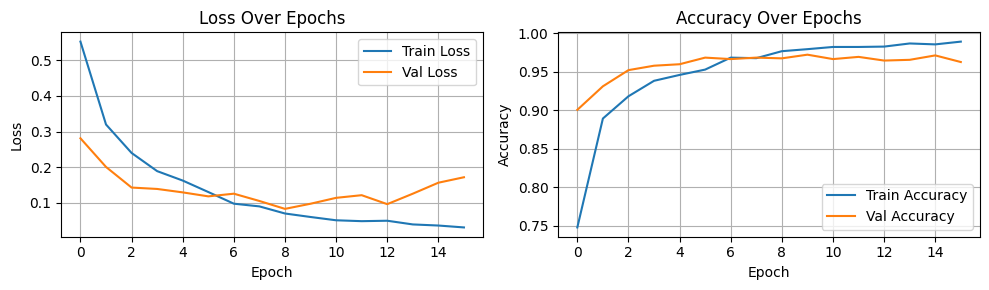

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['val_acc'], label='Val Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

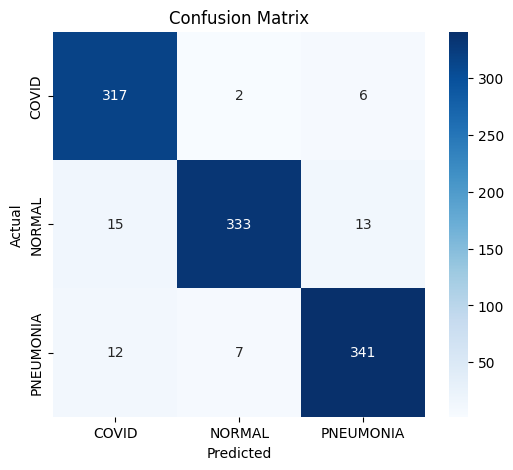

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["COVID","NORMAL","PNEUMONIA"],
            yticklabels=["COVID","NORMAL","PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds,
                            target_names=["COVID","NORMAL","PNEUMONIA"]))

              precision    recall  f1-score   support

       COVID       0.92      0.98      0.95       325
      NORMAL       0.97      0.92      0.95       361
   PNEUMONIA       0.95      0.95      0.95       360

    accuracy                           0.95      1046
   macro avg       0.95      0.95      0.95      1046
weighted avg       0.95      0.95      0.95      1046



## **Visualise Predictions**

We take a batch of chest X-ray images from the validation set and compare the model’s predictions with the true labels.

- **Green title** → correct prediction ✓
- **Red title** → incorrect prediction ✗

This helps us quickly understand how well the model performs and where it makes mistakes (e.g., confusing COVID with Pneumonia).

In [ ]:
import random

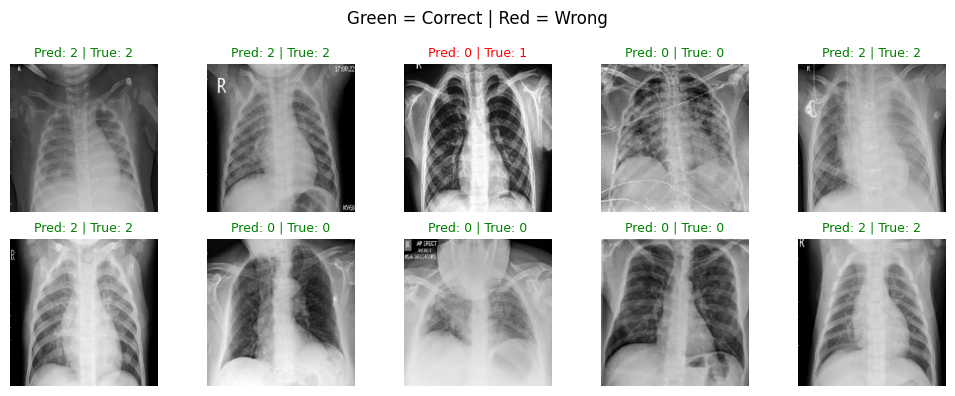

In [ ]:
import matplotlib.pyplot as plt

model.eval()

# Get one batch from validation loader
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()

    ax.imshow(img, cmap='gray')

    # Color: green = correct, red = wrong
    color = 'green' if preds[i] == labels[i] else 'red'

    ax.set_title(
        f"Pred: {preds[i].item()} | True: {labels[i].item()}",
        color=color,
        fontsize=9
    )

    ax.axis('off')

plt.suptitle("Green = Correct | Red = Wrong", fontsize=12)
plt.tight_layout()
plt.show()

- Accuracy → overall performance
- Confusion matrix → where model is wrong
- Predictions → real output behavior

**Important**:
“Model is not just about accuracy, but understanding mistakes”

# **Testing on Unseen Data**

After training and validation, we test the model on **completely unseen images** to simulate real-world usage.

- These images were **not used during training or validation**
- Helps evaluate **true model performance**
- Shows how well the model generalizes to new data

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import os

zip_path = "/content/Unseen_Data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("unseen_data")

print(os.listdir("unseen_data"))

['Covid-Unseen-Data', 'Pneumonia-Unseen-Data', 'Normal-Unseen-Data']


## **Prepare Unseen Data for Prediction**

We first inspect the extracted folders to understand the structure of unseen data.

Then, we convert the folder-based dataset into a structured DataFrame:

- Each image path is stored
- Folder names are used as labels
- This format allows us to reuse our prediction pipeline easily

In [ ]:
import os

print(os.listdir("unseen_data"))

['Covid-Unseen-Data', 'Pneumonia-Unseen-Data', 'Normal-Unseen-Data']


In [ ]:
print(os.listdir("unseen_data/Covid-Unseen-Data"))

['covid_808.png', 'covid_4711.png', 'covid_3097.png', 'covid_2203.png', 'covid_2146.png', 'covid_3314.png', 'covid_377.png', 'covid_3548.png', 'covid_722.png', 'covid_1636.png', 'covid_2069.png', 'covid_374.png', 'covid_535.png', 'covid_2694.png', 'covid_2559.png', 'covid_1926.png', 'covid_2452.png', 'covid_2356.png', 'covid_2829.png', 'covid_232.png', 'covid_2886.png', 'covid_2509.png', 'covid_979.png', 'covid_396.png', 'covid_346.png', 'covid_2732.png', 'covid_3101.png', 'covid_4650.png', 'covid_4587.png', 'covid_1639.png', 'covid_435.png', 'covid_3513.png', 'covid_2059.png', 'covid_4482.png', 'covid_2413.png', 'covid_1851.png', 'covid_2798.png', 'covid_2370.png', 'covid_4547.png', 'covid_2108.png', 'covid_4631.png', 'covid_3794.png', 'covid_1790.png', 'covid_3923.png', 'covid_3832.png', 'covid_3418.png', 'covid_2501.png', 'covid_2187.png', 'covid_1325.png', 'covid_2839.png', 'covid_2390.png', 'covid_3491.png', 'covid_2616.png', 'covid_3582.png', 'covid_3433.png', 'covid_2980.png', '

In [ ]:
import os
import pandas as pd

dataset_path = "unseen_data"

data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    # Map folder → label
    if "covid" in folder.lower():
        label = "COVID"
    elif "normal" in folder.lower():
        label = "NORMAL"
    elif "pneumonia" in folder.lower():
        label = "PNEUMONIA"
    else:
        continue

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)

        if os.path.isfile(img_path):
            data.append([img_path, label])

unseen_df = pd.DataFrame(data, columns=["image_path", "label"])

unseen_df.head()

,image_path,label
0,unseen_data/Covid-Unseen-Data/covid_808.png,COVID
1,unseen_data/Covid-Unseen-Data/covid_4711.png,COVID
2,unseen_data/Covid-Unseen-Data/covid_3097.png,COVID
3,unseen_data/Covid-Unseen-Data/covid_2203.png,COVID
4,unseen_data/Covid-Unseen-Data/covid_2146.png,COVID


In [ ]:
label_map = {"COVID": 0, "NORMAL": 1, "PNEUMONIA": 2}

unseen_df["label"] = unseen_df["label"].map(label_map)

## **Visualise Model Generalization**

Now, we test the trained model on unseen images and compare predictions with true labels.

- Random samples are used to simulate real-world inputs
- **Green Title** → correct prediction
- **Red Title** → incorrect prediction

This helps us visually understand how well the model generalizes to new data.

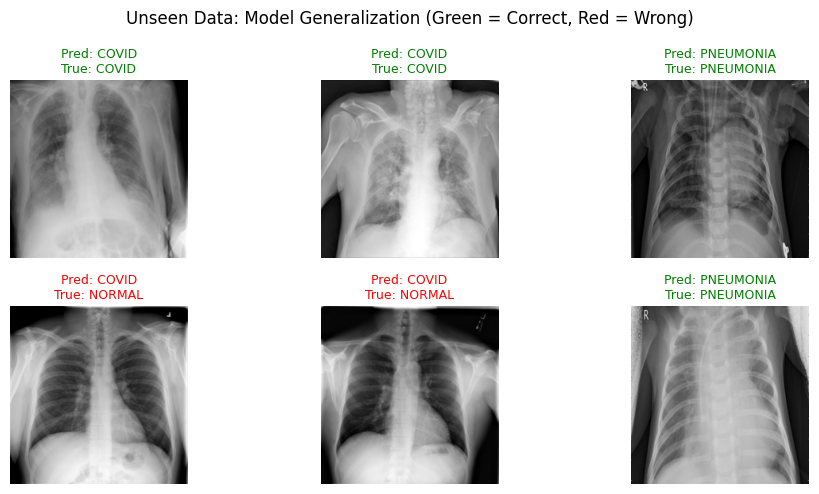

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import random

label_names = ["COVID", "NORMAL", "PNEUMONIA"]

model.eval()

plt.figure(figsize=(10,5))

# randomly pick 6 images
indices = random.sample(range(len(unseen_df)), 6)

for i, idx in enumerate(indices):
    img_path = unseen_df["image_path"][idx]
    true_label = unseen_df["label"][idx]

    # Load image
    img = Image.open(img_path).convert("L")
    img = img.resize((224, 224))

    # Preprocess
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = torch.tensor(img_array, dtype=torch.float32).to(device)

    # Prediction
    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, dim=1).item()

    # Color: correct / wrong
    color = "green" if pred == true_label else "red"

    # Plot
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(
        f"Pred: {label_names[pred]}\nTrue: {label_names[true_label]}",
        color=color,
        fontsize=9
    )
    plt.axis('off')

plt.suptitle("Unseen Data: Model Generalization (Green = Correct, Red = Wrong)")
plt.tight_layout()
plt.show()

# **Save the Model**

We save the trained model so it can be reused later without retraining.

- **state_dict()** stores all learned weights
- Saved as a **.pth file** (PyTorch format)
- Can be loaded later for predictions

In [ ]:
torch.save(model.state_dict(), "xray_cnn_model.pth")

print("Model saved successfully!")

Model saved successfully!
